In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [21]:
df = pd.read_csv("heart.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Dataset Shape:
(1025, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


In [22]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

X = df.drop("target", axis=1)
y = df["target"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_prediction = nb_model.predict(X_test_scaled)

In [26]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

In [27]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_prediction = knn_model.predict(X_test_scaled)

In [28]:
models = {
    "Naive Bayes": nb_prediction,
    "Decision Tree": dt_prediction,
    "KNN": knn_prediction
}

results = []

for name, prediction in models.items():
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction, zero_division=0)
    recall = recall_score(y_test, prediction, zero_division=0)
    f1 = f1_score(y_test, prediction, zero_division=0)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(results_df.round(4))

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8293,0.8070,0.8762,0.8402
1,Decision Tree,0.8390,0.8214,0.8762,0.8479
2,KNN,0.8634,0.8738,0.8571,0.8654


In [29]:
print("NAIVE BAYES CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        nb_prediction,
        target_names=["No Disease", "Disease"],
        zero_division=0
    )
)

print("DECISION TREE CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        dt_prediction,
        target_names=["No Disease", "Disease"],
        zero_division=0
    )
)

print("KNN CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        knn_prediction,
        target_names=["No Disease", "Disease"],
        zero_division=0
    )
)

NAIVE BAYES CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.86      0.78      0.82       100
     Disease       0.81      0.88      0.84       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.86      0.80      0.83       100
     Disease       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205

KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.85      0.87      0.86       100
     Disease       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.8

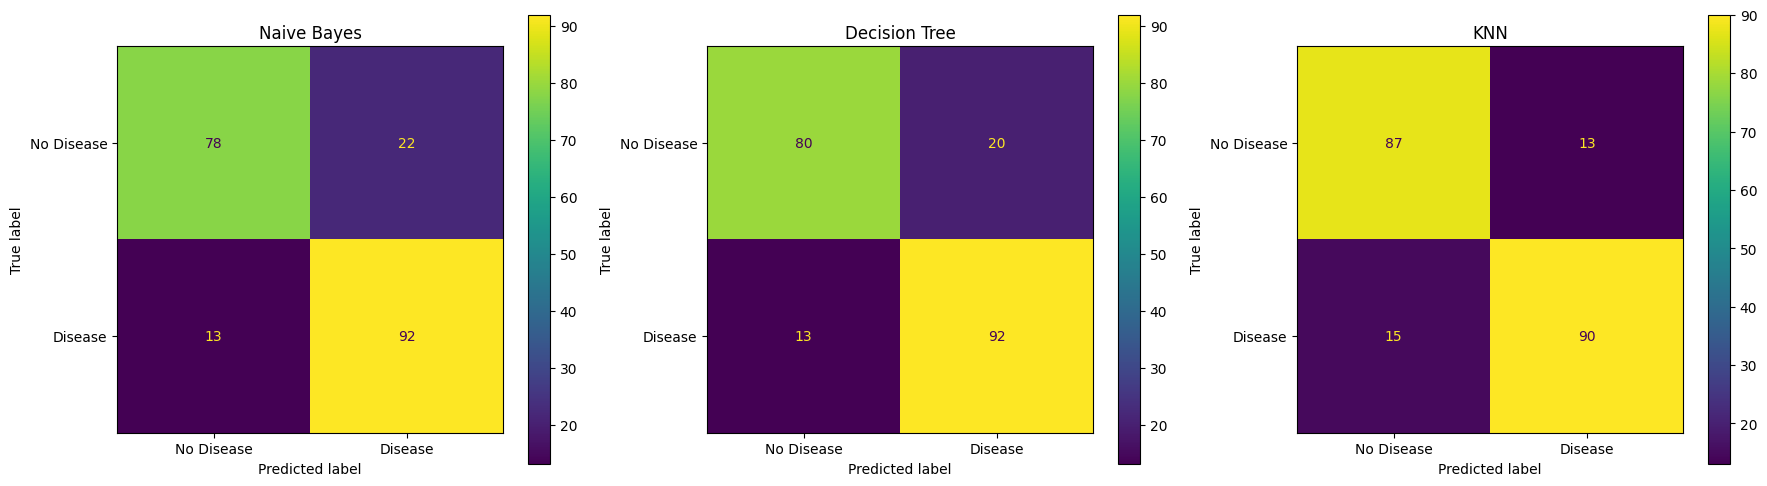

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, nb_prediction),
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[0])

axes[0].set_title("Naive Bayes")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, dt_prediction),
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, knn_prediction),
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[2])

axes[2].set_title("KNN")

plt.tight_layout()
plt.show()

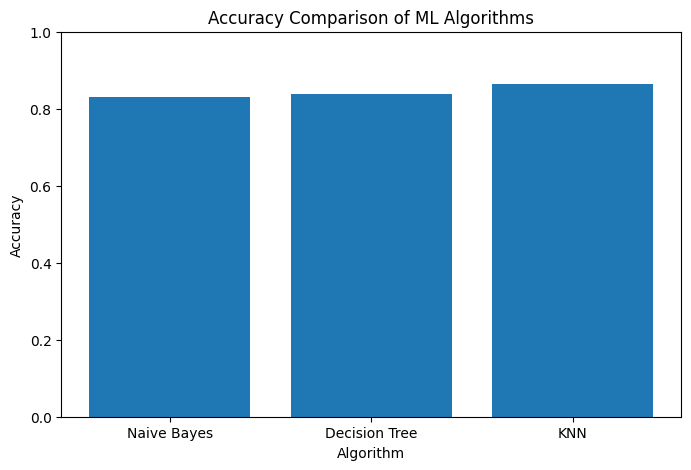

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"]
)

plt.ylim(0, 1)
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Algorithms")

plt.show()

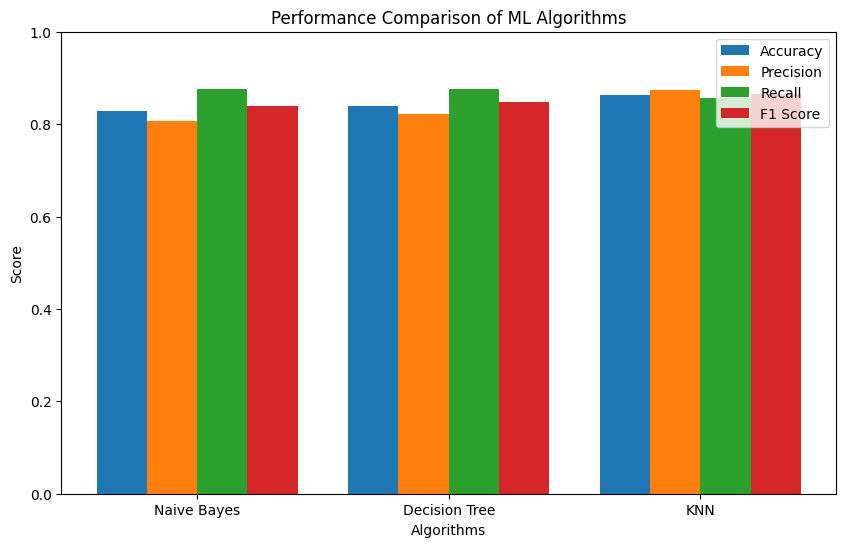

In [32]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(results_df["Algorithm"]))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x + width * 1.5,
    results_df["Algorithm"]
)

plt.ylim(0, 1)
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.title("Performance Comparison of ML Algorithms")
plt.legend()

plt.show()

In [33]:
best_algorithm = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Algorithm"
]

best_accuracy = results_df["Accuracy"].max()

print("BEST PERFORMING ALGORITHM:")
print(best_algorithm)

print("\nBEST ACCURACY:")
print(round(best_accuracy * 100, 2), "%")

BEST PERFORMING ALGORITHM:
KNN

BEST ACCURACY:
86.34 %


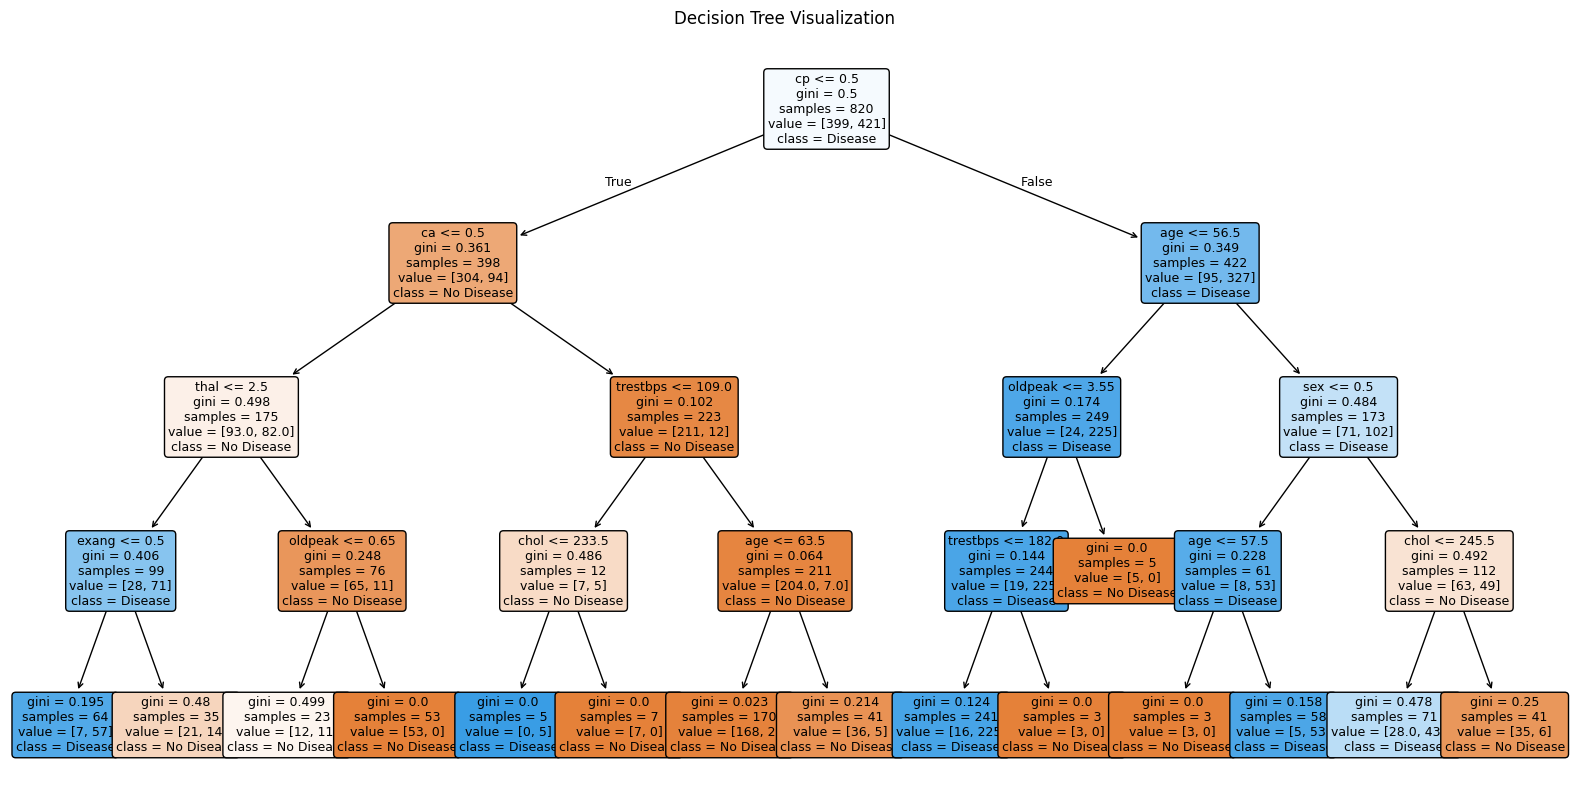

In [34]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization")
plt.show()